In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
ROOT_DIR = Path.cwd()
ss = ROOT_DIR/'data'/'superstoreSales.csv'
df = pd.read_csv(ss)
df.head()

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D� Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


In [14]:
sum_df = pd.DataFrame({
    'missing': df.isnull().sum(),
    'unique': df.nunique(),
    'datatype': df.dtypes
})
sum_df

,missing,unique,datatype
Row ID,0,232,int64
Order ID,0,159,int64
Order Date,0,153,datetime64[us]
Order Priority,0,5,str
Order Quantity,0,50,int64
Sales,0,232,float64
Discount,0,12,float64
Ship Mode,0,3,str
Profit,0,232,float64
Unit Price,0,177,float64


In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.set_index(df['Order Date'])
monthly =  df['Sales'].resample('ME').sum()
df['monthly'] = monthly
df


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date,monthly
Order Date,,,,,,,,,,,,,,,,,,,,,
2010-10-13,1,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010,NaN
2012-10-01,49,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012,NaN
2012-10-01,50,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D� Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012,NaN
2011-07-10,80,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011,NaN
2010-08-28,85,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-06-27,3644,26051,2010-06-27,Not Specified,31,251.7500,0.07,Regular Air,22.46,8.33,...,Northwest Territories,Northwest Territories,Home Office,Technology,Computer Peripherals,"80 Minute Slim Jewel Case CD-R , 10/Pack - Sta...",Small Pack,0.52,6/28/2010,NaN
2012-10-29,3649,26116,2012-10-29,Critical,36,697.4100,0.04,Regular Air,81.71,18.97,...,Northwest Territories,Northwest Territories,Small Business,Office Supplies,Paper,Computer Printout Paper with Letter-Trim Perfo...,Small Box,0.37,10/30/2012,NaN
2010-01-16,3658,26182,2010-01-16,Not Specified,30,4684.9000,0.01,Delivery Truck,-549.27,150.98,...,Northwest Territories,Northwest Territories,Corporate,Furniture,Bookcases,Bush Mission Pointe Library,Jumbo Box,0.65,1/19/2010,NaN


Using Superstore Sales, draw a two-panel figure: a bar chart of sales by region beside a
line chart of monthly sales.

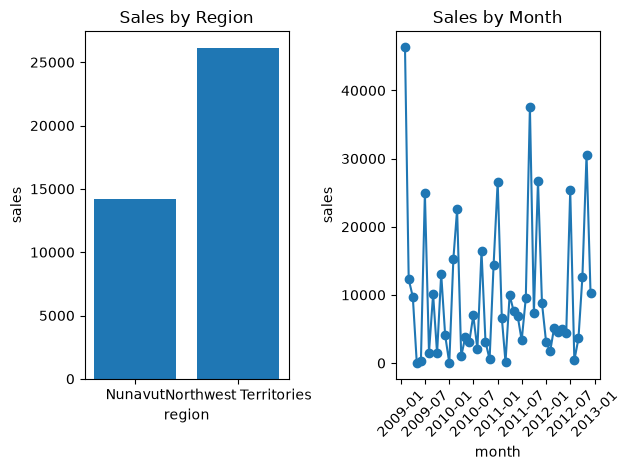

In [18]:
monthly_sales = df.set_index(['Order Date'])['Sales'].resample('ME').sum()

fig, (ax1,ax2) = plt.subplots(1,2)

ax1.bar(df['Region'], df['Sales'])
ax1.set_title('Sales by Region')
ax1.set_ylabel('sales')
ax1.set_xlabel('region')

ax2.plot(monthly_sales.index, monthly_sales.values, marker='o')
ax2.tick_params(axis='x', rotation=45)
ax2.set_title('Sales by Month')
ax2.set_ylabel('sales')
ax2.set_xlabel('month')

plt.tight_layout()
plt.show()

In [4]:
tips = ROOT_DIR/'data'/'tips.csv'
ti = pd.read_csv(tips)
ti.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Using the seaborn tips dataset, plot the distribution of total_bill and, separately, tip
vs total_bill as a scatter.

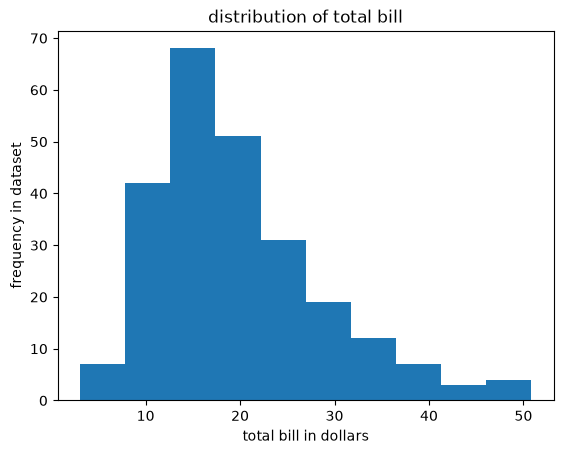

In [13]:
plt.hist(ti['total_bill'])
plt.title('distribution of total bill')
plt.xlabel('total bill in dollars')
plt.ylabel('frequency in dataset')
plt.show()

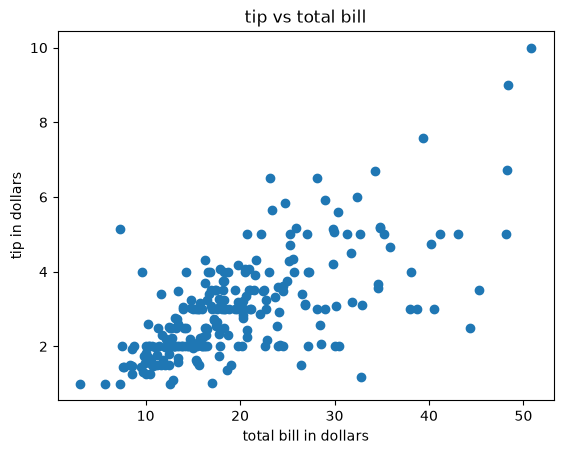

In [17]:
plt.scatter(ti['total_bill'], ti['tip'])
plt.title('tip vs total bill')
plt.xlabel('total bill in dollars')
plt.ylabel('tip in dollars')
plt.savefig('tip vs total.png')
plt.show()

Save one of your charts to a PNG file. See above ^^^